In [41]:
from get_cpoints import h_to_v_rep
from convex_hull import generate_convex_hull
import matplotlib.pyplot as plt
import numpy as np

verts_originales = np.array([(0,0,0), (0,1,0), (0,0,1), (0,1,1),
                             (2,0,1), (2,1,0), (2,0,1), (2,1,1)])

A, b = generate_convex_hull(verts_originales)

vertices_calculados = h_to_v_rep(A, b)
print(vertices_calculados)

#plotear los vértices
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(verts_originales[:, 0], verts_originales[:, 1], verts_originales[:, 2], 
           c='blue', s=150, label='Puntos Input Originales', alpha=0.5)

ax.scatter(vertices_calculados[:, 0], vertices_calculados[:, 1], vertices_calculados[:, 2], 
           c='red', s=50, label='Vértices Calculados (h_to_v_rep)', marker='X')

# Etiquetas y leyenda
ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_zlabel('Eje Z (Discreto)')
ax.set_title('Comparación: Puntos Originales vs Vértices Calculados')
ax.legend()

# Ajustar límites para ver mejor
all_pts = np.vstack((verts_originales, vertices_calculados))
ax.set_xlim(all_pts[:,0].min()-0.5, all_pts[:,0].max()+0.5)
ax.set_ylim(all_pts[:,1].min()-0.5, all_pts[:,1].max()+0.5)
ax.set_zlim(all_pts[:,2].min()-0.5, all_pts[:,2].max()+0.5)

plt.show()

TypeError: 'tuple' object is not callable

In [3]:
# Crear un diccionario vacío
mi_diccionario = {}

# Agregar una nueva llave y su valor
mi_diccionario["nombre"] = "Ana"
mi_diccionario["edad"] = 28

print(mi_diccionario)
# Salida: {'nombre': 'Ana', 'edad': 28}

mi_diccionario.update({"ciudad": "Madrid", "profesion": "Ingeniera"})
print(mi_diccionario)



{'nombre': 'Ana', 'edad': 28}
{'nombre': 'Ana', 'edad': 28, 'ciudad': 'Madrid', 'profesion': 'Ingeniera'}


In [12]:
import numpy as np
vertices = np.asarray([(0, 0, 0), (0, 0, 1), (0, 1, 0), (0, 1, 1),
            (2, 0, 0), (2, 0, 1), (2, 1, 0), (2, 1, 1)])
vertices = vertices[:, 1:]
punto_interior = np.asarray(np.mean(vertices, axis = 0))

print(punto_interior)


[0.5 0.5]


In [34]:
import numpy as np

def ordenar_vertices(vertices_slice):
    """
    ordenar los vértices (de cada slice) para poder ocupar la fórmula en la sgte función
    input:
        vertices_slice : vértices por correspondientes a cada slice
    """
    # Trabajamos como array
    vertices_slice = np.asarray(vertices_slice)
    # Primero me quedo con las coordenadas (x,y)
    vertices = vertices_slice[:, 1:]

    # Elegir un centro
    # Podría ser el centro de Chebyshev, pero necesito su H representation para eso
    # Así que por mientra trabajo con el promedio de los puntos
    # Que es un punto interior por lo menos
    centro = np.asarray(np.mean(vertices, axis = 0))


    # Sacarle vector a los vértices desde el centro hasta cada uno
    vectores = []
    for i in vertices:
        u_i = i - centro
        vectores.append(u_i)

    # Ahora calcular el ángulo respecto al centro con cada uno de los vectores
    # El primero vector en de referencia
    u_ref = vectores[0]

    # Como arccos me entrega valores entre [0,pi], voy a ordenarlos por los puntos a su izquierda
    # y los puntos a su derecha, de menor a mayor ángulo
    # Luego los puedo juntar en una lista
    puntos_izq = {}
    puntos_der = {}
    
    vectores_a_ordenar = vectores[1:] # Sublista con los que hay que ordenar
    for i in vectores_a_ordenar:
        # Siguiendo la fórmula theta_i = arccos( <u_ref, u_i> / (||u_ref|| ||u_i||) )
        theta_i = np.arccos(np.dot(u_ref, i)/(np.linalg.norm(u_ref) * np.linalg.norm(i)))

        #determinar si quedó a la izquiera o la derecha
        det = u_ref[0]*i[1] - u_ref[1]*i[0]
        if det >= 0:
            puntos_izq.update({tuple(i) : theta_i})
        else:
            puntos_der.update({tuple(i) : theta_i})

    # Ahora hay que sortear los diccionarios según ángulo
    puntos_ordenados_izq = dict(sorted(puntos_izq.items(), key = lambda item : item[1]))
    puntos_ordenados_der = dict(sorted(puntos_der.items(), key = lambda item : item[1]))

    # Y juntar las listas
    puntos_ordenados = []

    for i in puntos_ordenados_izq.keys():
        puntos_ordenados.append(i)
    for i in reversed(puntos_ordenados_der.keys()):
        puntos_ordenados.append(i)
       
        
    return puntos_ordenados

slice: 0
[[0.         0.46612444 0.32244843]
 [0.         0.98827637 0.41696491]
 [0.         0.29594643 0.04288964]
 [0.         0.98047449 0.42002166]
 [0.         0.81976477 0.55413911]]
slice: 1
[[1.         0.57619977 0.35244846]
 [1.         0.11409122 0.80261665]
 [1.         0.66098064 0.40354854]
 [1.         0.16016798 0.54209285]
 [1.         0.67875028 0.52455786]]
slice: 2
[[2.         0.66370574 0.03230929]
 [2.         0.89801205 0.21875496]
 [2.         0.01241392 0.23413485]
 [2.         0.64403291 0.12019637]
 [2.         0.62450842 0.40361073]]


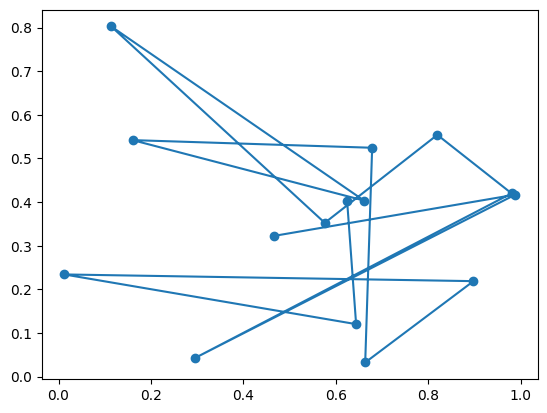

In [23]:
from convex_hull import random_vertices_by_fiber
import matplotlib.pyplot as plt
verts = random_vertices_by_fiber([0,1,2], 2, 5)

for z, i in enumerate(range(0, len(verts), 5)):
    grupo = verts[i:i+5]
    print("slice:", z)
    print(grupo)

x = [v[1] for v in verts]
y = [v[2] for v in verts]

plt.plot(x, y, marker="o")
plt.show()

slice: 0
[[0.         0.46612444 0.32244843]
 [0.         0.98827637 0.41696491]
 [0.         0.29594643 0.04288964]
 [0.         0.98047449 0.42002166]
 [0.         0.81976477 0.55413911]]


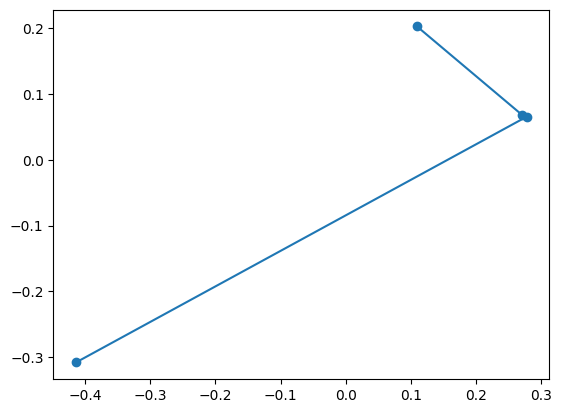

slice: 1
[[1.         0.57619977 0.35244846]
 [1.         0.11409122 0.80261665]
 [1.         0.66098064 0.40354854]
 [1.         0.16016798 0.54209285]
 [1.         0.67875028 0.52455786]]


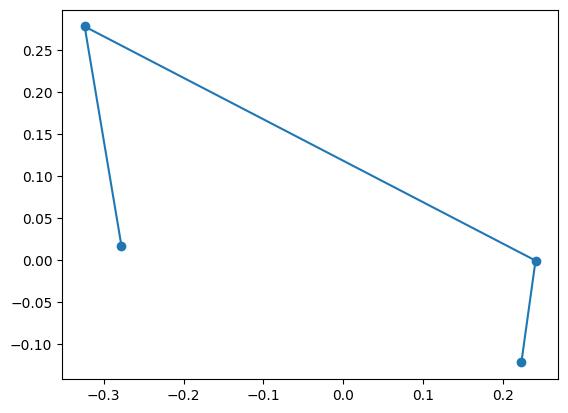

slice: 2
[[2.         0.66370574 0.03230929]
 [2.         0.89801205 0.21875496]
 [2.         0.01241392 0.23413485]
 [2.         0.64403291 0.12019637]
 [2.         0.62450842 0.40361073]]


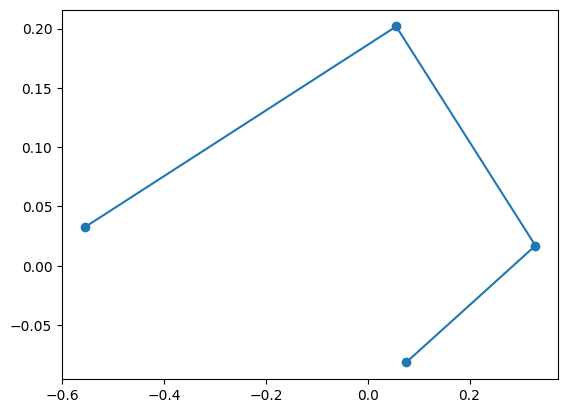

[[(np.float64(-0.41417087009815734), np.float64(-0.30840310912368935)), (np.float64(0.2781590665077609), np.float64(0.06567215899704365)), (np.float64(0.27035718930758446), np.float64(0.06872890709235285)), (np.float64(0.10964746992668617), np.float64(0.2028463614548574))], [(np.float64(0.22294266271058566), np.float64(-0.12150433190312404)), (np.float64(0.2407123008233915), np.float64(-0.0004950153462409679)), (np.float64(-0.32394675611001994), np.float64(0.2775637800308215)), (np.float64(-0.27786999733340595), np.float64(0.0170399764500222))], [(np.float64(0.07549830233426014), np.float64(-0.08160487289609542)), (np.float64(0.329477442005617), np.float64(0.016953719926181332)), (np.float64(0.05597381577889382), np.float64(0.2018094874907821)), (np.float64(-0.5561206891178031), np.float64(0.03233361514655675))]]


In [39]:
orden_final = []
for z, i in enumerate(range(0, len(verts), 5)):
    grupo = verts[i:i+5]
    print("slice:", z)
    print(grupo)

    vertices_ordenados = ordenar_vertices(grupo)
    orden_final.append(vertices_ordenados)

    x = [v[0] for v in vertices_ordenados]
    y = [v[1] for v in vertices_ordenados]

    plt.plot(x, y, marker="o")
    plt.show()
print(orden_final)
